# 02 — Beam Pattern / PSF

Compute and compare the Point Spread Function (PSF) for each candidate array pattern.
The PSF is the beamformer output when a single point source is placed at boresight — it
directly shows main-lobe width and side-lobe levels without any source signal.

**Method:** Frequency-domain Delay-and-Sum (D&S) array factor.
For a planar array in the x-y plane, the array factor for a source at direction cosines (u, v)
when steered to boresight is:

$$AF(u,v,f) = \frac{1}{N} \left| \sum_{n=1}^{N} \exp\!\left( j \frac{2\pi f}{c} (u\,x_n + v\,y_n) \right) \right|$$

where $u = \sin\theta\cos\phi$, $v = \sin\theta\sin\phi$ are direction cosines.

**Key metrics extracted:**
- **HPBW** — half-power (−3 dB) beamwidth along azimuth
- **MSL** — maximum side-lobe level relative to main lobe peak (dB)

**Comparisons made:**
1. All five patterns at 1, 4, 8 kHz — 1D PSF
2. Underbrink 2D PSF at 1, 4, 8 kHz
3. Underbrink arms sweep: H ∈ {4, 6, 8, 12, 16} at 4 kHz
4. Spiral angle: α = 22° vs α = 35° for H=8×12 at 4 and 8 kHz
5. Summary HPBW and MSL table

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.spatial.distance import cdist
import pandas as pd

plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 10

C         = 343.0
R_MAX     = 0.150
R_MIN     = 0.025
N_MICS    = 96
D_NYQUIST = C / (2 * 8000)

## Array Geometry Functions (from notebook 01)

In [2]:
def underbrink_array(n_arms, n_per_arm, r_min=R_MIN, r_max=R_MAX, spiral_angle_deg=22.0):
    """Equal arc-length Underbrink multi-arm log-spiral (US Patent 6,089,671)."""
    b         = 1.0 / np.tan(np.radians(spiral_angle_deg))
    sq        = np.sqrt(1.0 + b**2)
    theta_max = np.log(r_max / r_min) / b
    S_total   = r_min * sq / b * (np.exp(b * theta_max) - 1.0)
    s         = np.linspace(0.0, S_total, n_per_arm)
    theta_arm = np.log(1.0 + b * s / (r_min * sq)) / b
    r_arm     = r_min * np.exp(b * theta_arm)
    xs, ys = [], []
    for h in range(n_arms):
        offset = h * 2.0 * np.pi / n_arms
        t = theta_arm + offset
        xs.append(r_arm * np.cos(t))
        ys.append(r_arm * np.sin(t))
    return np.concatenate(xs), np.concatenate(ys)


def vogel_spiral(n=N_MICS, r_max=R_MAX):
    ga = np.radians(137.508)
    idx = np.arange(1, n + 1)
    r = np.sqrt(idx / n) * r_max
    return r * np.cos(idx * ga), r * np.sin(idx * ga)


def concentric_rings(n=N_MICS, r_max=R_MAX, n_rings=6):
    radii  = np.linspace(r_max / n_rings, r_max, n_rings)
    counts = np.round(radii / radii.sum() * n).astype(int)
    counts[-1] += n - counts.sum()
    xs, ys = [], []
    for r, c in zip(radii, counts):
        a = np.linspace(0, 2 * np.pi, c, endpoint=False)
        xs.append(r * np.cos(a)); ys.append(r * np.sin(a))
    return np.concatenate(xs), np.concatenate(ys)


def regular_grid(n=N_MICS, r_max=R_MAX):
    sp = np.sqrt(np.pi * r_max**2 / n)
    xs, ys = [], []
    for x in np.arange(-r_max, r_max + sp, sp):
        for y in np.arange(-r_max, r_max + sp, sp):
            if x**2 + y**2 <= r_max**2:
                xs.append(x); ys.append(y)
    return np.array(xs), np.array(ys)

## PSF Computation

In [3]:
def psf_1d(x, y, freq, n_points=1000, az_range=(-89, 89)):
    """
    1D PSF along azimuth (elevation = 0).  Returns (angles_deg, psf_linear).

    AF(az) = |mean_n exp(j * 2pi * f/c * sin(az) * x_n)|
    """
    az    = np.linspace(*np.radians(az_range), n_points)
    phase = 2 * np.pi * freq / C * np.outer(np.sin(az), x)
    af    = np.abs(np.mean(np.exp(1j * phase), axis=1))
    return np.degrees(az), af


def psf_2d(x, y, freq, fov_deg=45, n_points=300):
    """
    2D PSF over a square direction-cosine grid.
    Returns (u_axis, v_axis, psf_2d) where u,v ∈ [-sin(fov), +sin(fov)].
    """
    uv     = np.linspace(-np.sin(np.radians(fov_deg)),
                          np.sin(np.radians(fov_deg)), n_points)
    ug, vg = np.meshgrid(uv, uv)
    phase  = 2 * np.pi * freq / C * (
        ug[:, :, None] * x[None, None, :] +
        vg[:, :, None] * y[None, None, :]
    )
    return uv, uv, np.abs(np.mean(np.exp(1j * phase), axis=2))


def to_db(af, floor_db=-40):
    """Normalise to 0 dB peak and apply floor."""
    with np.errstate(divide='ignore'):
        db = 20 * np.log10(af / af.max())
    return np.clip(db, floor_db, 0)


def hpbw(angles_deg, psf_db, level_db=-3):
    """Beamwidth at `level_db` (degrees).  Returns NaN if indeterminate."""
    above = psf_db >= level_db
    idx   = np.where(np.diff(above.astype(int)))[0]
    if len(idx) < 2:
        return np.nan
    return float(angles_deg[idx[-1]] - angles_deg[idx[0]])


def first_null_angle(angles_deg, psf_db):
    """
    Angle of the first null to the right of boresight.
    Finds the first local minimum of the PSF outward from centre.
    """
    centre  = len(angles_deg) // 2
    half    = psf_db[centre:]
    d1, d2  = np.diff(half[:-1]), np.diff(half[1:])
    # Local minimum: slope changes from negative to positive
    mins    = np.where((d1 < 0) & (d2 > 0))[0]
    if len(mins) == 0:
        return None
    return float(np.abs(angles_deg[centre + mins[0] + 1]))


def max_sidelobe(angles_deg, psf_db):
    """
    Peak side-lobe level (dB) relative to main lobe.

    Excludes the main lobe by finding the first null outward from boresight
    and masking everything within that angle.  Falls back to 1.5× HPBW if
    no null is found.
    """
    null = first_null_angle(angles_deg, psf_db)
    if null is None:
        bw   = hpbw(angles_deg, psf_db, -3)
        null = (bw / 2 * 1.5) if not np.isnan(bw) else 10.0
    mask = np.abs(angles_deg) > null
    if not mask.any():
        return np.nan
    return float(psf_db[mask].max())

## Pattern Comparison — 1D PSF at 1, 4, 8 kHz

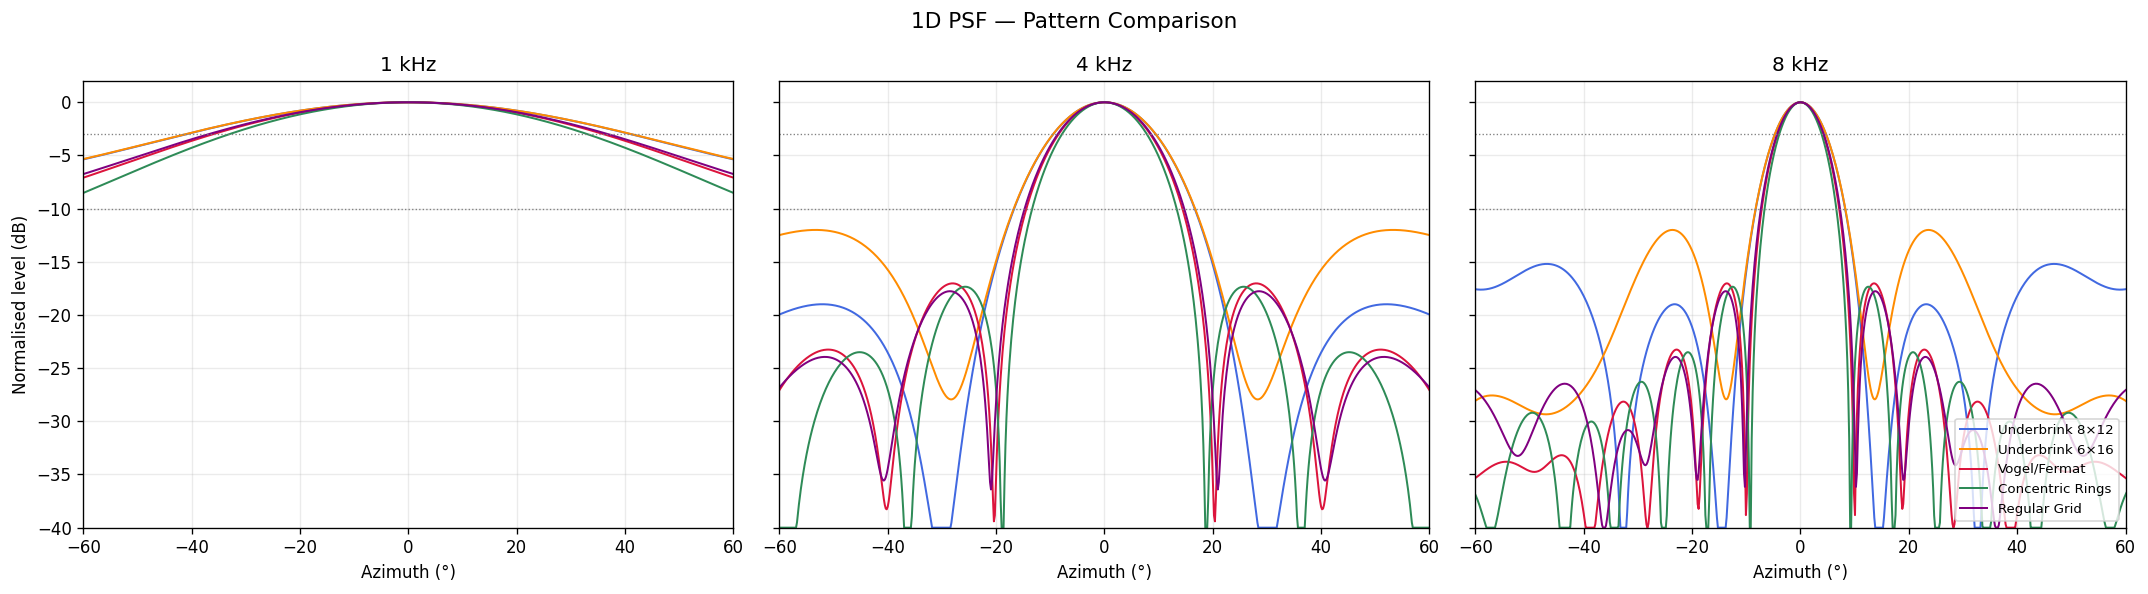

In [4]:
arrays = {
    "Underbrink 8×12": underbrink_array(8, 12),
    "Underbrink 6×16": underbrink_array(6, 16),
    "Vogel/Fermat":    vogel_spiral(),
    "Concentric Rings": concentric_rings(),
    "Regular Grid":    regular_grid(),
}

freqs   = [1000, 4000, 8000]
colors  = ['royalblue', 'darkorange', 'crimson', 'seagreen', 'purple']
floor   = -40

fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)

for ax, freq in zip(axes, freqs):
    for (name, (x, y)), color in zip(arrays.items(), colors):
        az, af = psf_1d(x, y, freq)
        ax.plot(az, to_db(af, floor), label=name, color=color, linewidth=1.2)
    ax.axhline(-3,  color='gray', linestyle=':', linewidth=0.8)
    ax.axhline(-10, color='gray', linestyle=':', linewidth=0.8)
    ax.set_xlim(-60, 60)
    ax.set_ylim(floor, 2)
    ax.set_title(f"{freq//1000} kHz")
    ax.set_xlabel("Azimuth (°)")
    ax.grid(True, alpha=0.25)

axes[0].set_ylabel("Normalised level (dB)")
axes[2].legend(fontsize=8, loc='lower right')
fig.suptitle("1D PSF — Pattern Comparison", fontsize=13)
plt.tight_layout()
plt.savefig("psf_pattern_comparison.png", dpi=150, bbox_inches='tight')
plt.show()

## Underbrink 8×12 — 2D PSF at 1, 4, 8 kHz

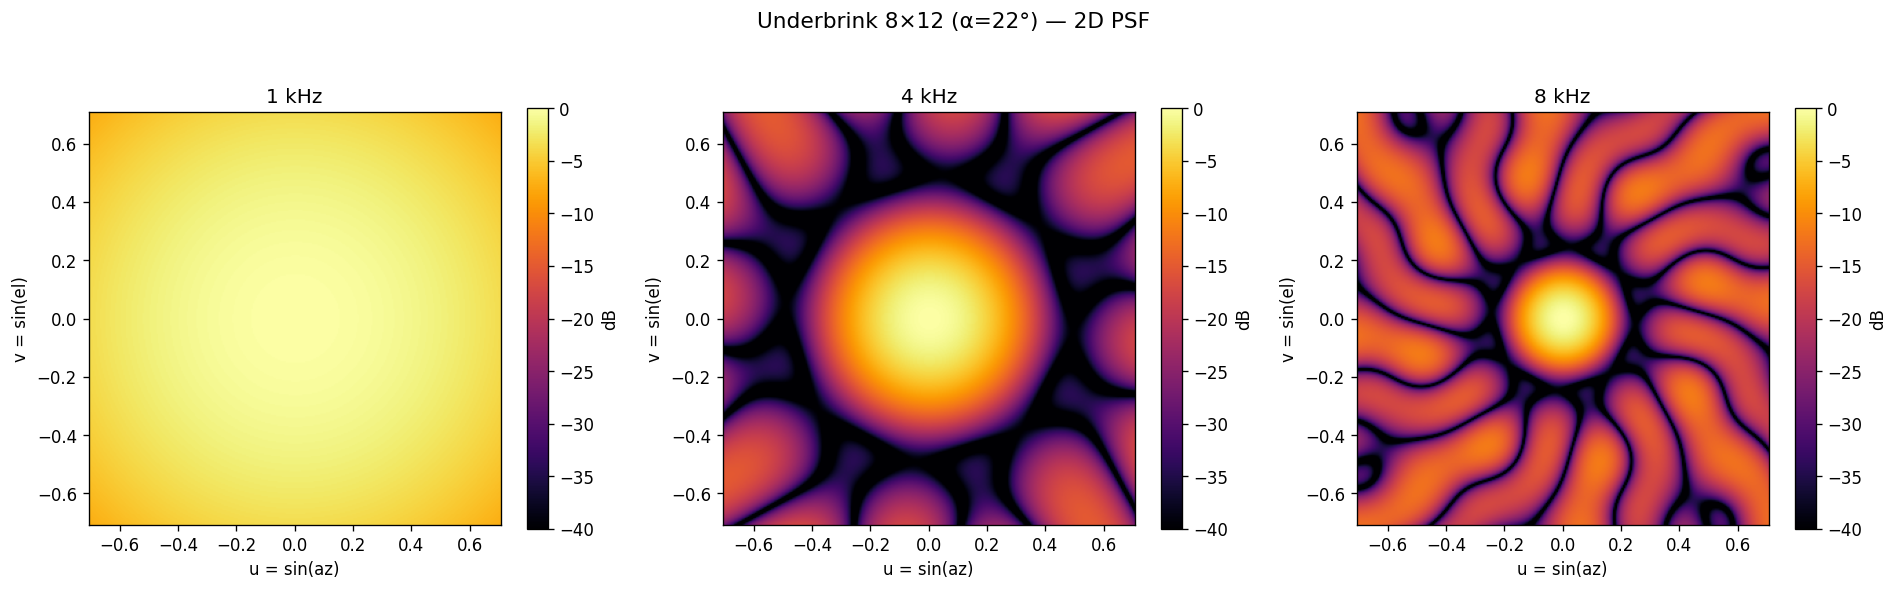

In [5]:
x_ub, y_ub = underbrink_array(8, 12)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, freq in zip(axes, freqs):
    u, v, psf = psf_2d(x_ub, y_ub, freq, fov_deg=45, n_points=300)
    db = to_db(psf, floor_db=-40)
    im = ax.imshow(db, extent=[u[0], u[-1], v[0], v[-1]],
                   origin='lower', cmap='inferno', vmin=-40, vmax=0, aspect='equal')
    ax.set_title(f"{freq//1000} kHz")
    ax.set_xlabel("u = sin(az)")
    ax.set_ylabel("v = sin(el)")
    fig.colorbar(im, ax=ax, label="dB", shrink=0.8)

fig.suptitle("Underbrink 8×12 (α=22°) — 2D PSF", fontsize=13)
plt.tight_layout()
plt.savefig("psf_2d_underbrink_8x12.png", dpi=150, bbox_inches='tight')
plt.show()

## HPBW and MSL Summary Table

In [6]:
all_arrays = {
    "Underbrink 8×12, α=22°":  underbrink_array(8, 12, spiral_angle_deg=22),
    "Underbrink 8×12, α=35°":  underbrink_array(8, 12, spiral_angle_deg=35),
    "Underbrink 6×16, α=22°":  underbrink_array(6, 16, spiral_angle_deg=22),
    "Underbrink 12×8, α=22°":  underbrink_array(12, 8, spiral_angle_deg=22),
    "Vogel/Fermat":             vogel_spiral(),
    "Concentric Rings":         concentric_rings(),
    "Regular Grid":             regular_grid(),
}

rows = []
for freq in freqs:
    for name, (x, y) in all_arrays.items():
        az, af = psf_1d(x, y, freq)
        db     = to_db(af)
        rows.append({
            "Array":        name,
            "Freq (kHz)":   freq // 1000,
            "HPBW (°)":     round(hpbw(az, db, -3), 1),
            "10dB BW (°)":  round(hpbw(az, db, -10), 1),
            "MSL (dB)":     round(max_sidelobe(az, db), 1),
        })

df = pd.DataFrame(rows)
df.set_index(["Array", "Freq (kHz)"])

,,HPBW (°),10dB BW (°),MSL (dB)
Array,Freq (kHz),,,
"Underbrink 8×12, α=22°",1,82.0,NaN,-5.5
"Underbrink 8×12, α=35°",1,82.0,NaN,-5.6
"Underbrink 6×16, α=22°",1,82.3,NaN,-5.5
"Underbrink 12×8, α=22°",1,81.6,NaN,-5.6
Vogel/Fermat,1,72.0,168.6,-6.1
Concentric Rings,1,65.9,134.3,-6.2
Regular Grid,1,73.8,NaN,-6.0
"Underbrink 8×12, α=22°",4,18.9,33.5,-7.2
"Underbrink 8×12, α=35°",4,18.9,33.1,-14.4


## Underbrink Arms Sweep — PSF at 4 kHz

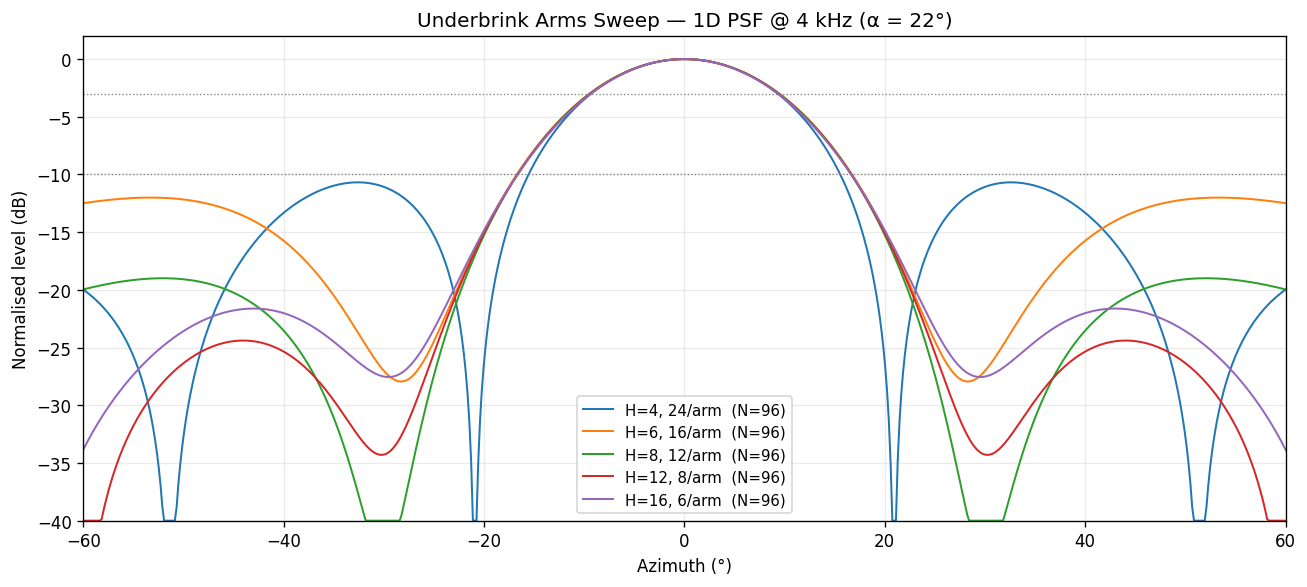

In [7]:
arm_configs = [(4, 24), (6, 16), (8, 12), (12, 8), (16, 6)]
freq        = 4000

fig, ax = plt.subplots(figsize=(11, 5))

for h, n in arm_configs:
    x, y = underbrink_array(h, n)
    az, af = psf_1d(x, y, freq)
    ax.plot(az, to_db(af, floor), label=f"H={h}, {n}/arm  (N={h*n})", linewidth=1.2)

ax.axhline(-3,  color='gray', linestyle=':', linewidth=0.8)
ax.axhline(-10, color='gray', linestyle=':', linewidth=0.8)
ax.set_xlim(-60, 60)
ax.set_ylim(floor, 2)
ax.set_xlabel("Azimuth (°)")
ax.set_ylabel("Normalised level (dB)")
ax.set_title("Underbrink Arms Sweep — 1D PSF @ 4 kHz (α = 22°)")
ax.legend(fontsize=9)
ax.grid(True, alpha=0.25)
plt.tight_layout()
plt.savefig("psf_arms_sweep_4kHz.png", dpi=150, bbox_inches='tight')
plt.show()

In [8]:
# HPBW and MSL for each arms config
rows = []
for freq in [1000, 4000, 8000]:
    for h, n in arm_configs:
        x, y   = underbrink_array(h, n)
        az, af = psf_1d(x, y, freq)
        db     = to_db(af)
        rows.append({
            "Config":      f"H={h}, {n}/arm",
            "Freq (kHz)":  freq // 1000,
            "HPBW (°)":    round(hpbw(az, db, -3), 1),
            "10dB BW (°)": round(hpbw(az, db, -10), 1),
            "MSL (dB)":    round(max_sidelobe(az, db), 1),
        })

pd.DataFrame(rows).set_index(["Config", "Freq (kHz)"])

,,HPBW (°),10dB BW (°),MSL (dB)
Config,Freq (kHz),,,
"H=4, 24/arm",1,80.9,NaN,-5.9
"H=6, 16/arm",1,82.3,NaN,-5.5
"H=8, 12/arm",1,82.0,NaN,-5.5
"H=12, 8/arm",1,81.6,NaN,-5.6
"H=16, 6/arm",1,80.9,NaN,-5.5
"H=4, 24/arm",4,18.5,31.0,-7.6
"H=6, 16/arm",4,18.9,33.5,-12.0
"H=8, 12/arm",4,18.9,33.5,-7.2
"H=12, 8/arm",4,18.9,33.1,-24.4


## Spiral Angle Comparison: α = 22° vs α = 35° for H=8×12

Primary question: does the wider spiral (α=35°, better minimum spacing from notebook 01)
also give better or worse side-lobe levels?

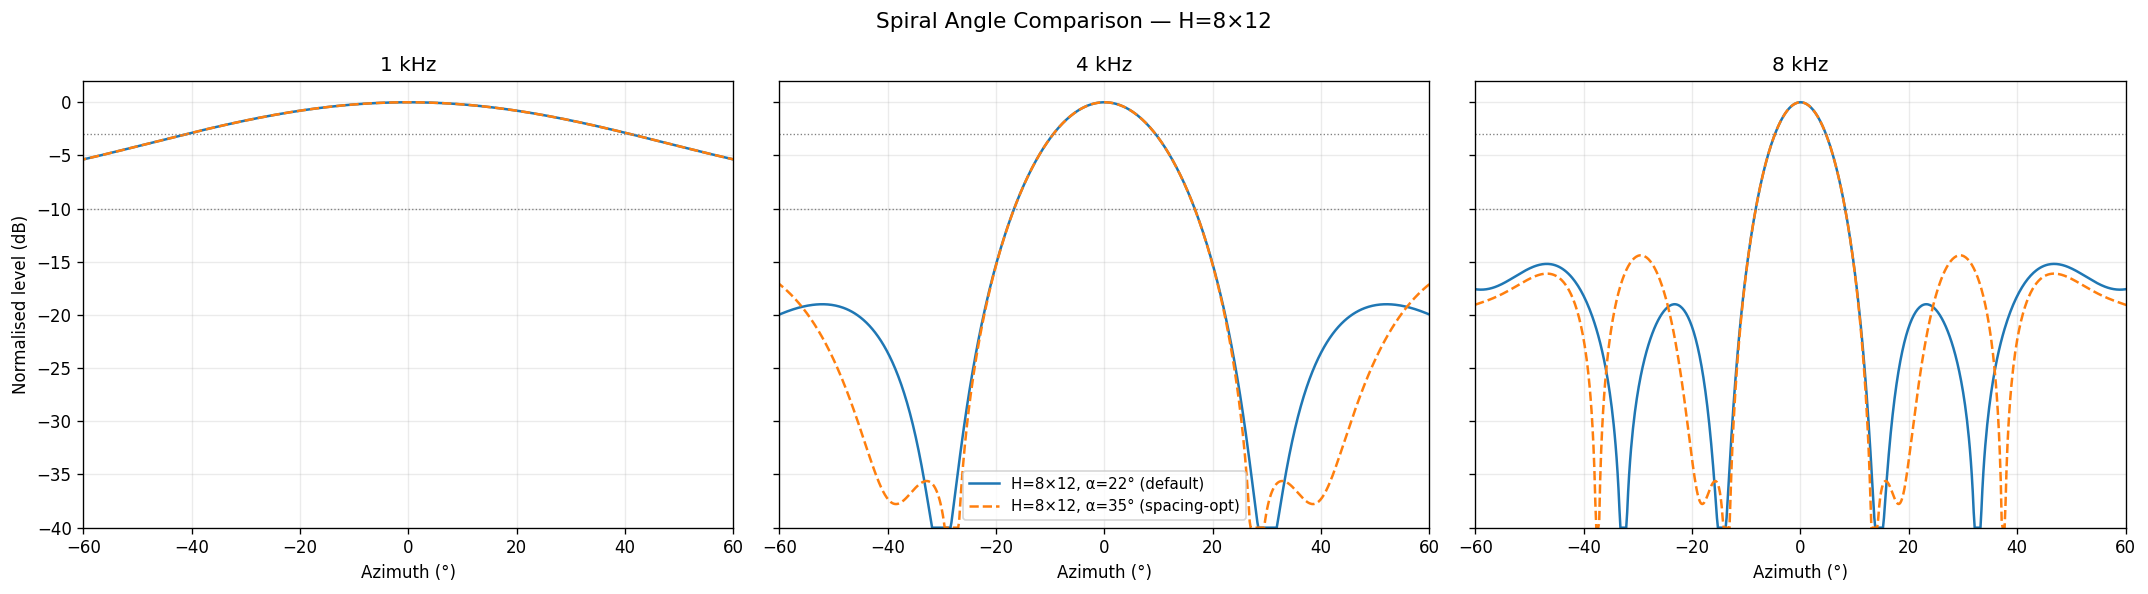

In [9]:
candidates = {
    "H=8×12, α=22° (default)": underbrink_array(8, 12, spiral_angle_deg=22),
    "H=8×12, α=35° (spacing-opt)": underbrink_array(8, 12, spiral_angle_deg=35),
}

fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)

for ax, freq in zip(axes, freqs):
    for (label, (x, y)), ls in zip(candidates.items(), ['-', '--']):
        az, af = psf_1d(x, y, freq)
        ax.plot(az, to_db(af, floor), linestyle=ls, linewidth=1.5, label=label)
    ax.axhline(-3,  color='gray', linestyle=':', linewidth=0.8)
    ax.axhline(-10, color='gray', linestyle=':', linewidth=0.8)
    ax.set_xlim(-60, 60)
    ax.set_ylim(floor, 2)
    ax.set_title(f"{freq//1000} kHz")
    ax.set_xlabel("Azimuth (°)")
    ax.grid(True, alpha=0.25)

axes[0].set_ylabel("Normalised level (dB)")
axes[1].legend(fontsize=9)
fig.suptitle("Spiral Angle Comparison — H=8×12", fontsize=13)
plt.tight_layout()
plt.savefig("psf_angle_comparison.png", dpi=150, bbox_inches='tight')
plt.show()

In [10]:
# Tabulate HPBW and MSL for the two candidates
rows = []
for freq in freqs:
    for label, (x, y) in candidates.items():
        az, af = psf_1d(x, y, freq)
        db     = to_db(af)
        rows.append({
            "Config":      label,
            "Freq (kHz)":  freq // 1000,
            "HPBW (°)":    round(hpbw(az, db, -3), 1),
            "10dB BW (°)": round(hpbw(az, db, -10), 1),
            "MSL (dB)":    round(max_sidelobe(az, db), 1),
        })

pd.DataFrame(rows).set_index(["Config", "Freq (kHz)"])

,,HPBW (°),10dB BW (°),MSL (dB)
Config,Freq (kHz),,,
"H=8×12, α=22° (default)",1,82.0,NaN,-5.5
"H=8×12, α=35° (spacing-opt)",1,82.0,NaN,-5.6
"H=8×12, α=22° (default)",4,18.9,33.5,-7.2
"H=8×12, α=35° (spacing-opt)",4,18.9,33.1,-14.4
"H=8×12, α=22° (default)",8,9.3,16.4,-13.1
"H=8×12, α=35° (spacing-opt)",8,9.3,16.4,-14.4


## Continuous Spiral Angle Sweep — MSL and HPBW vs. α

Sweep α from 5° to 45° and track HPBW and MSL at 4 kHz to find the Pareto-optimal angle.

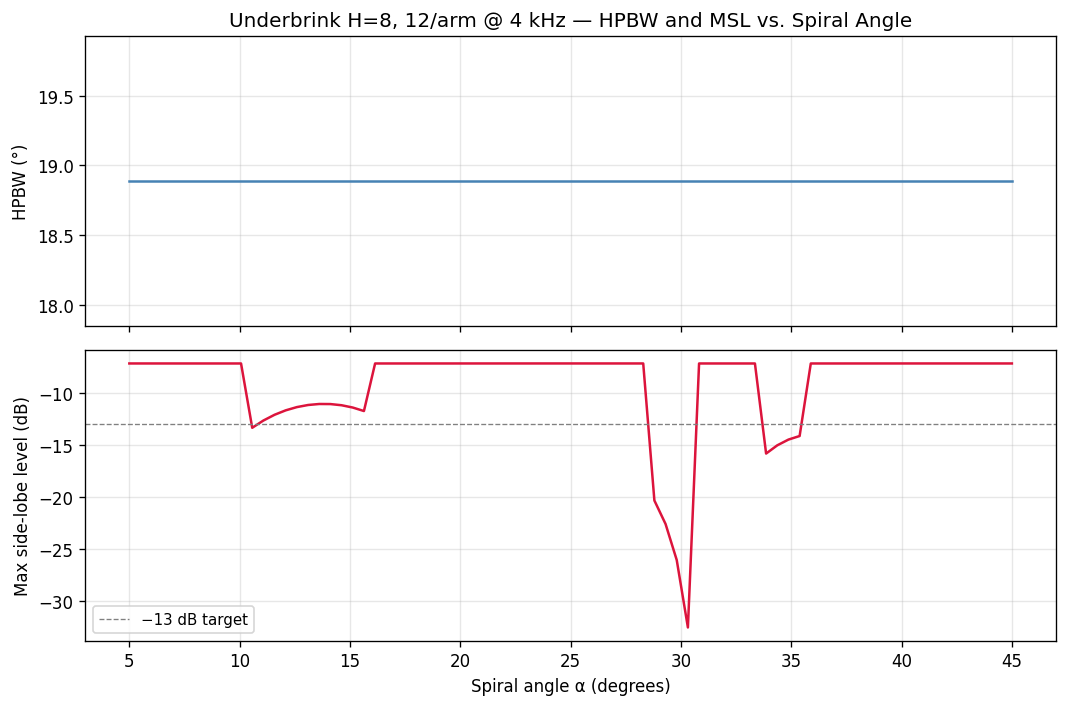

Best MSL at α = 30.3°:  MSL = -32.5 dB,  HPBW = 18.9°


In [11]:
freq   = 4000
angles = np.linspace(5, 45, 80)
hpbws, msls = [], []

for angle in angles:
    x, y   = underbrink_array(8, 12, spiral_angle_deg=angle)
    az, af = psf_1d(x, y, freq)
    db     = to_db(af)
    hpbws.append(hpbw(az, db, -3))
    msls.append(max_sidelobe(az, db))

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(9, 6), sharex=True)

ax1.plot(angles, hpbws, color='steelblue')
ax1.set_ylabel("HPBW (°)")
ax1.set_title("Underbrink H=8, 12/arm @ 4 kHz — HPBW and MSL vs. Spiral Angle")
ax1.grid(True, alpha=0.3)

ax2.plot(angles, msls, color='crimson')
ax2.axhline(-13, color='gray', linestyle='--', linewidth=0.8, label='−13 dB target')
ax2.set_ylabel("Max side-lobe level (dB)")
ax2.set_xlabel("Spiral angle α (degrees)")
ax2.legend(fontsize=9)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("psf_angle_vs_metrics.png", dpi=150, bbox_inches='tight')
plt.show()

best_msl_idx = np.argmin(msls)
print(f"Best MSL at α = {angles[best_msl_idx]:.1f}°:  MSL = {msls[best_msl_idx]:.1f} dB,  HPBW = {hpbws[best_msl_idx]:.1f}°")

## Best Configuration: 2D PSF Comparison Side-by-Side

Show the 2D PSF for the winning configuration vs. the regular grid baseline at 4 kHz.

Using α = 30.3° for best-config 2D PSF


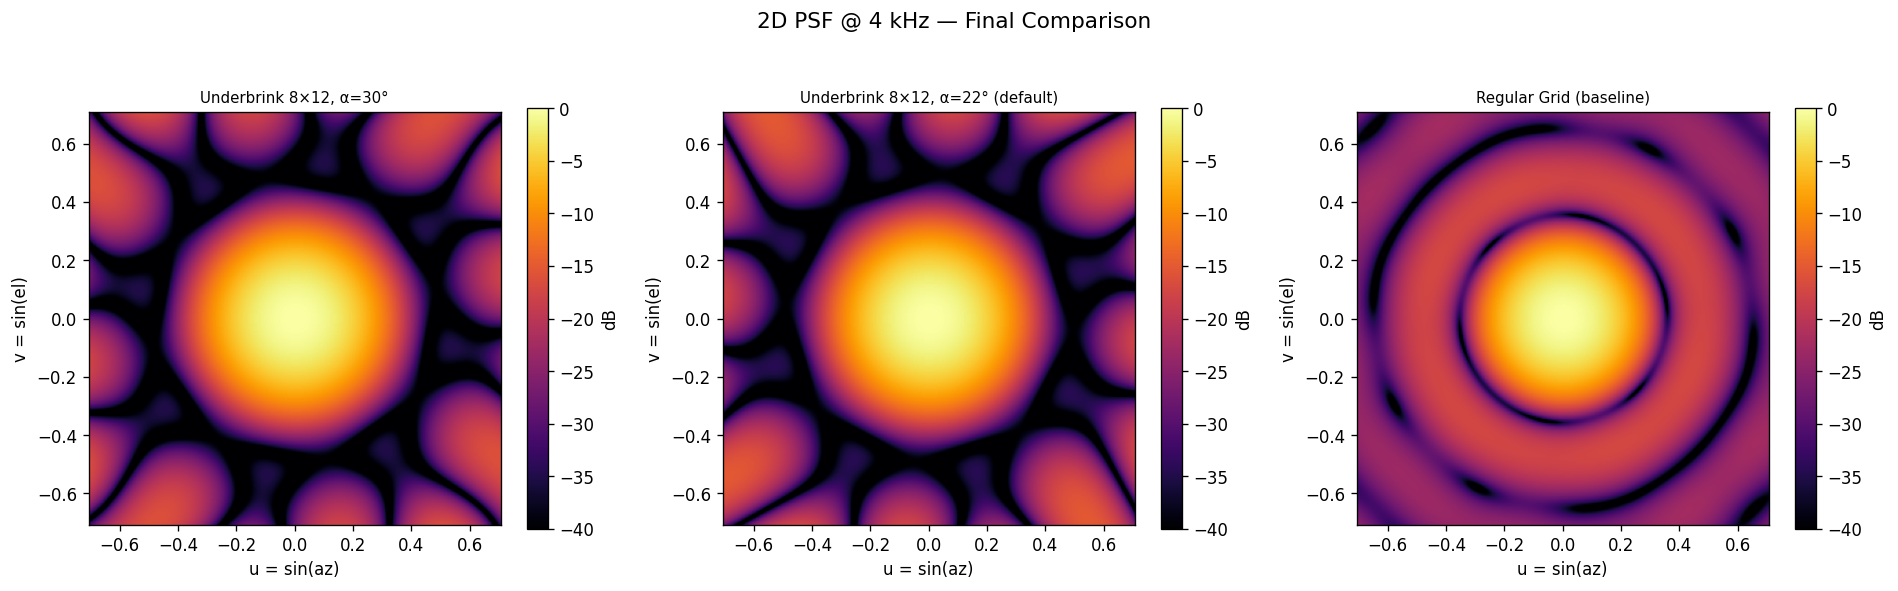

In [12]:
# Find the alpha that minimises MSL for H=8×12
best_angle = float(angles[np.argmin(msls)])
print(f"Using α = {best_angle:.1f}° for best-config 2D PSF")

final_arrays = {
    f"Underbrink 8×12, α={best_angle:.0f}°": underbrink_array(8, 12, spiral_angle_deg=best_angle),
    "Underbrink 8×12, α=22° (default)":     underbrink_array(8, 12, spiral_angle_deg=22),
    "Regular Grid (baseline)":               regular_grid(),
}

freq = 4000
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, (label, (x, y)) in zip(axes, final_arrays.items()):
    u, v, psf = psf_2d(x, y, freq, fov_deg=45, n_points=300)
    db = to_db(psf, floor_db=-40)
    im = ax.imshow(db, extent=[u[0], u[-1], v[0], v[-1]],
                   origin='lower', cmap='inferno', vmin=-40, vmax=0, aspect='equal')
    ax.set_title(label, fontsize=9)
    ax.set_xlabel("u = sin(az)")
    ax.set_ylabel("v = sin(el)")
    fig.colorbar(im, ax=ax, label="dB", shrink=0.8)

fig.suptitle(f"2D PSF @ {freq//1000} kHz — Final Comparison", fontsize=13)
plt.tight_layout()
plt.savefig("psf_2d_final_comparison.png", dpi=150, bbox_inches='tight')
plt.show()